# ARTI501 – Natural Language Processing
## Lab 3: N-Gram Model

| | |
|---|---|
| **Student Name** | Maan A Alghamdi |
| **Student ID** | 2240001433 |


# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

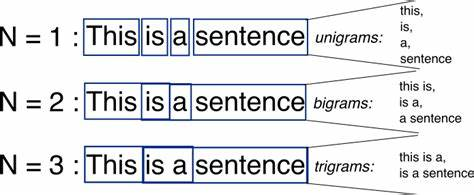

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** an n-gram consisting of a single item from a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$ count of (A) \div corpus length $

In [1]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [2]:
### Calculate counts of each word

unique_string = set(word_tokenize(string))

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques)
    words_frq.append((uniques, frq))

words_frq

[('his', 1),
 ('moses', 2),
 ('but', 1),
 ('are', 1),
 ('erroneously', 1),
 ('roses', 1),
 ('supposes', 2),
 ('toeses', 1)]

In [3]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)):
    pro = words_frq[count][1]/len(string)
    probab.append(pro)

print('the probabilities are: ',probab)

the probabilities are:  [0.015151515151515152, 0.030303030303030304, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.015151515151515152, 0.030303030303030304, 0.015151515151515152]


In [4]:
probabilities = []
for i,j in zip(unique_string, probab):
    probabilities.append((i,j))
probabilities

[('his', 0.015151515151515152),
 ('moses', 0.030303030303030304),
 ('but', 0.015151515151515152),
 ('are', 0.015151515151515152),
 ('erroneously', 0.015151515151515152),
 ('roses', 0.015151515151515152),
 ('supposes', 0.030303030303030304),
 ('toeses', 0.015151515151515152)]

## Bigram

**Bigram** an n-gram consisting of two items from a sequence
- Two words that are used together to mean something specific

$ countof(A \ then \ B) \div countof(A) $

### Method 1

In [5]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nl.bigrams(word_tokenize(string))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [6]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [7]:
import nltk as nl
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nl.trigrams(word_tokenize(string))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [8]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in 1.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

n-1 padding is added.



In [9]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [10]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.

- Build the vocabulary: to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create and Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.


**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [11]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [12]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model
print(lm.vocab)
print(len(lm.vocab))

<Vocabulary with cutoff=1 unk_label='<UNK>' and 11 items>
11


In [13]:
lm.vocab.lookup(['moses','supposes'])

('moses', 'supposes')

In [14]:
lm.vocab.lookup(['moses'])

('moses',)

### counts for unigrams and bigrams

In [15]:
print(lm.counts['moses'])
# a then b
print(lm.counts[['moses']]['supposes'])

2
2


In [16]:
print(lm.score('moses')) #Calculate Bigram Probabilities

0.16666666666666666


Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [17]:
# b then a
lm.score("supposes", ["moses"])

1.0

### Evaluating n_grams models using preplexity

**Preplexity** is the probability of the test set normalized by the number of words

In [18]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test))

1.0


---
# Lab 3 – Part 1
## Example: Trigram model on the Reuters corpus

Reuters corpus is a collection of 10,788 news documents totaling 1.3 million words.

In [19]:
import nltk
for pkg in ['reuters', 'punkt', 'punkt_tab', 'stopwords']:
    nltk.download(pkg, quiet=True)

Import the important libraries:

In [20]:
from nltk.corpus import reuters
from nltk import trigrams
from collections import Counter, defaultdict

**Note:** `defaultdict` is the same as the normal dictionary except that it never raises a `KeyError`.

The defaultdict will be the N-gram model:

In [21]:
model = defaultdict(lambda: defaultdict(lambda: 0))

Count the frequency of co-occurrence and save it in the defaultdict:

In [22]:
for sentence in reuters.sents():
    for w1, w2, w3 in trigrams(sentence, pad_right=True, pad_left=True):
        model[(w1, w2)][w3] += 1

Transform the counts into probabilities:

In [23]:
for w1_w2 in model:
    total_count = float(sum(model[w1_w2].values()))
    for w3 in model[w1_w2]:
        model[w1_w2][w3] /= total_count

Use the N-gram model to predict the next word:

In [24]:
print(dict(model['price', 'is']))

{'pre': 0.023255813953488372, 'subject': 0.06976744186046512, 'quoted': 0.023255813953488372, 'weighted': 0.023255813953488372, 'payable': 0.023255813953488372, 'at': 0.046511627906976744, 'above': 0.023255813953488372, 'about': 0.06976744186046512, 'suject': 0.023255813953488372, 'approximately': 0.023255813953488372, 'similar': 0.023255813953488372, 'fair': 0.023255813953488372, '18': 0.023255813953488372, '19': 0.023255813953488372, 'reduced': 0.023255813953488372, 'usually': 0.023255813953488372, '50': 0.023255813953488372, 'too': 0.023255813953488372, 'very': 0.023255813953488372, 'to': 0.023255813953488372, 'now': 0.046511627906976744, 'calculated': 0.023255813953488372, 'relatively': 0.023255813953488372, 'in': 0.023255813953488372, 'likely': 0.023255813953488372, 'based': 0.046511627906976744, 'not': 0.023255813953488372, 'lower': 0.023255813953488372, 'around': 0.023255813953488372, 'revised': 0.046511627906976744, 'then': 0.023255813953488372, 'paid': 0.023255813953488372, '1

Generate a random piece of text using the N-gram model (outputs differ between runs; a seed is set here for reproducibility):

In [25]:
import random
random.seed(42)

text = ["today", "the"]
sentence_finished = False

while not sentence_finished:
    r = random.random()
    accumulator = .0
    for word in model[tuple(text[-2:])].keys():
        accumulator += model[tuple(text[-2:])][word]
        if accumulator >= r:
            text.append(word)
            break
    if text[-2:] == [None, None]:
        sentence_finished = True

print(' '.join([t for t in text if t]))

today the Turkish General Staff , said that RMJ employed some 300 mln dlrs of new conversion assignments at Geonex ' s huge foreign exchange trading .


---
## Task #1 (Part 1): Generating tweets using N-grams

In this task, we build an MLE model with bigrams to generate tweets.

1. Load the data – [Anonymous – Random Tweets | Kaggle](https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan)
2. Pre-process the data:
   * Remove any mentions
   * Remove hashtags
   * Remove RT
   * Remove any website
   * Remove extra symbols (emojis, punctuation, digits, non-Latin characters)
   * Remove extra spaces
3. Build an MLE model with bigrams
4. Evaluate the model

Before starting, install the library that handles emojis in tweets:
> pip install emoji

In [26]:
# !pip install emoji
import re
import emoji
import pandas as pd
from nltk.lm import MLE, Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
from nltk.util import ngrams

### 1. Load the data

In [27]:
TWEETS_PATH = 'data/tweets/Random Tweets from Pakistan- Cleaned- Anonymous.csv'

tweets_df = pd.read_csv(TWEETS_PATH, encoding='utf-8', encoding_errors='ignore', low_memory=False)
tweets_df = tweets_df[['full_text']].dropna()
print('Number of tweets:', len(tweets_df))
tweets_df.head()

Number of tweets: 202151


,full_text
0,تیرا لیڈر میرا لیڈر نواز شریف نواز شریف❤️ کیا...
1,"Happy birthday to my brother n boss , May you ..."
2,❤️❤️
3,`suspicious °jikook au jimin'in yaşadığı kasab...
4,Speaking of @SpiderMan... 😂 https://t.co/uGJ...


### 2. Pre-processing the data

In [28]:
def clean_tweet(tweet):
    tweet = emoji.replace_emoji(str(tweet), replace=' ')   # remove emojis
    tweet = re.sub(r'\bRT\b', ' ', tweet)                  # remove RT
    tweet = re.sub(r'@\w+', ' ', tweet)                     # remove mentions
    tweet = re.sub(r'#\w+', ' ', tweet)                     # remove hashtags
    tweet = re.sub(r'https?://\S+|www\.\S+', ' ', tweet)    # remove websites
    tweet = tweet.lower()
    tweet = re.sub(r'[^a-z\s]', ' ', tweet)                 # remove extra symbols
    tweet = re.sub(r'\s+', ' ', tweet).strip()              # remove extra spaces
    return tweet

tweets_df['clean_text'] = tweets_df['full_text'].apply(clean_tweet)
tweets_df = tweets_df[tweets_df['clean_text'] != '']       # drop tweets that became empty
print('Tweets after cleaning:', len(tweets_df))
tweets_df.head(10)

Tweets after cleaning: 143293


,full_text,clean_text
1,"Happy birthday to my brother n boss , May you ...",happy birthday to my brother n boss may you ha...
3,`suspicious °jikook au jimin'in yaşadığı kasab...,suspicious jikook au jimin in ya ad kasabada a...
4,Speaking of @SpiderMan... 😂 https://t.co/uGJ...,speaking of
5,"Alexa, skip to 2021",alexa skip to
6,Jb tm moon lover ho gy to sooraj to tappy ga na 😒,jb tm moon lover ho gy to sooraj to tappy ga na
7,Alexa skip to 2022 now,alexa skip to now
8,"But this was one of my first shoots, about 6 y...",but this was one of my first shoots about year...
9,Trying phoneix in 140 ping 🔥 https://t.co/CpjY...,trying phoneix in ping
10,Cant sleep 🥵🥱 So why not . https://t.co/WjmRMB...,cant sleep so why not
11,@n1ffyyy Ayy gonna miss you too 🥺,ayy gonna miss you too


In [29]:
tokenized_tweets = [tweet.split() for tweet in tweets_df['clean_text']]
print('Total tokens:', sum(len(t) for t in tokenized_tweets))
print(tokenized_tweets[:3])

Total tokens: 2182936
[['happy', 'birthday', 'to', 'my', 'brother', 'n', 'boss', 'may', 'you', 'have', 'many', 'many', 'more', 'you', 'are', 'gem'], ['suspicious', 'jikook', 'au', 'jimin', 'in', 'ya', 'ad', 'kasabada', 'aniden', 'ba', 'layan', 'cinayetler', 'onun', 'kendisini', 's', 'rekli', 'takip', 'eden', 'yeni', 'kom', 'usu', 'jungkook', 'tan', 'phelenmesine', 'neden', 'olur'], ['speaking', 'of']]


### 3. Build an MLE model with Bigram

In [30]:
train_data, padded_vocab = padded_everygram_pipeline(2, tokenized_tweets)

bigram_lm = MLE(2)
bigram_lm.fit(train_data, padded_vocab)
print(bigram_lm.vocab)

<Vocabulary with cutoff=1 unk_label='<UNK>' and 76195 items>


A trigram MLE model is also trained so that the trigram count and the probability of *'a'* given *'pakistan is'* can be computed.

In [31]:
train_data3, padded_vocab3 = padded_everygram_pipeline(3, tokenized_tweets)

trigram_lm = MLE(3)
trigram_lm.fit(train_data3, padded_vocab3)
print(trigram_lm.vocab)

<Vocabulary with cutoff=1 unk_label='<UNK>' and 76195 items>


### Counts

In [32]:
print("Count of unigram 'pakistan'       :", bigram_lm.counts['pakistan'])
print("Count of bigram  'is/pakistan'    :", bigram_lm.counts[['pakistan']]['is'])
print("Count of trigram 'a/pakistan is'  :", trigram_lm.counts[['pakistan', 'is']]['a'])

Count of unigram 'pakistan'       : 14010
Count of bigram  'is/pakistan'    : 699
Count of trigram 'a/pakistan is'  : 70


### Probabilities

In [33]:
print("P('pakistan' | <s>)        :", bigram_lm.score('pakistan', ['<s>']))
print("P('is' | 'pakistan')       :", bigram_lm.score('is', ['pakistan']))
print("P('a' | 'pakistan is')     :", trigram_lm.score('a', ['pakistan', 'is']))

P('pakistan' | <s>)        : 0.009714361483115016
P('is' | 'pakistan')       : 0.049892933618843685
P('a' | 'pakistan is')     : 0.10014306151645208


Checking the MLE formula manually: $P(w_i \mid w_{i-1}) = \dfrac{count(w_{i-1}\,w_i)}{count(w_{i-1})}$

In [34]:
print(bigram_lm.counts[['pakistan']]['is'] / bigram_lm.counts[['pakistan']].N())
print(trigram_lm.counts[['pakistan', 'is']]['a'] / trigram_lm.counts[['pakistan', 'is']].N())

0.049892933618843685
0.10014306151645208


### Generating tweets

In [35]:
def generate_tweet(lm, max_words=25, seed=None):
    words = []
    for word in lm.generate(max_words, text_seed=['<s>'], random_seed=seed):
        if word == '</s>':
            break
        if word != '<s>':
            words.append(word)
    return ' '.join(words)

for seed in range(1, 11):
    print(f'{seed:2d}.', generate_tweet(bigram_lm, seed=seed))

 1. chasing the same day in national security of binance


 2. wonderful yeonjun germany


 3. general populous cities multan dg isi


 4. gamcha is in darkness


 5. pakistan s sculpture as the upcoming conference is valid reasons why are not deserve forgiveness from


 6. that they have been


 7. hy


 8. for you are so beautiful city your dream of ncoc s in england tests and enlightened


 9. kindly help girls team


10. no matter of everyone th on sunday


### 4. Evaluate the model – Perplexity

Perplexity is the inverse probability of the test set normalized by the number of words: $PP(W) = P(w_1 w_2 \dots w_N)^{-1/N}$. Lower is better.

In [36]:
# Perplexity of the bigram MLE model on bigrams of a sample sentence
test_sentence = 'pakistan is a beautiful country'.split()
test_bigrams = list(ngrams(pad_both_ends(test_sentence, n=2), n=2))
print(test_bigrams)
print('Perplexity (sample sentence):', bigram_lm.perplexity(test_bigrams))

[('<s>', 'pakistan'), ('pakistan', 'is'), ('is', 'a'), ('a', 'beautiful'), ('beautiful', 'country'), ('country', '</s>')]
Perplexity (sample sentence): 34.189522733995545


In [37]:
# Perplexity of the model over a sample of tweets from the corpus
sample_bigrams = [bg for tweet in tokenized_tweets[:1000]
                  for bg in ngrams(pad_both_ends(tweet, n=2), n=2)]
print('Perplexity of the bigram MLE model (1000 tweets):', bigram_lm.perplexity(sample_bigrams))

Perplexity of the bigram MLE model (1000 tweets): 100.89407448972351


**Note:** a pure MLE model assigns probability 0 to any bigram it never saw, so its perplexity on unseen text is infinite. To evaluate on held-out data we split the tweets into train/test sets and also train a Laplace (add-one) smoothed bigram model.

In [38]:
import random
random.seed(0)
shuffled = tokenized_tweets[:]
random.shuffle(shuffled)
split = int(0.9 * len(shuffled))
train_tweets, test_tweets = shuffled[:split], shuffled[split:]

train_mle, vocab_mle = padded_everygram_pipeline(2, train_tweets)
mle_split = MLE(2)
mle_split.fit(train_mle, vocab_mle)

train_lap, vocab_lap = padded_everygram_pipeline(2, train_tweets)
laplace_split = Laplace(2)
laplace_split.fit(train_lap, vocab_lap)

held_out_bigrams = [bg for tweet in test_tweets[:2000]
                    for bg in ngrams(pad_both_ends(tweet, n=2), n=2)]

print('Held-out perplexity – MLE bigram     :', mle_split.perplexity(held_out_bigrams))
print('Held-out perplexity – Laplace bigram :', laplace_split.perplexity(held_out_bigrams))

Held-out perplexity – MLE bigram     : inf
Held-out perplexity – Laplace bigram : 4723.845854682878


---
# Lab 3 – Part 2
## Task #1: Text Analysis and NLP (IMDB reviews)

1. Load the dataset from a CSV file – [IMDB Dataset of 50K Movie Reviews | Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)
2. Pre-process the text data: tokenize, remove punctuation, lowercase, remove English stop words
3. Calculate statistics: total reviews, average word count per review, number of reviews containing *good* / *bad*
4. Create a word frequency histogram of the most common words
5. Print the results of the analysis

In [39]:
import string
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

### 1. Load the dataset

In [40]:
IMDB_PATH = 'data/imdb/IMDB Dataset.csv'

imdb_df = pd.read_csv(IMDB_PATH)
print(imdb_df.shape)
imdb_df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 2. Pre-process the text data

In [41]:
def preprocess(text):
    text = re.sub(r'<.*?>', ' ', str(text))                   # remove HTML tags such as <br />
    tokens = word_tokenize(text.lower())                      # tokenize + lowercase
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t.strip(string.punctuation) for t in tokens]    # remove punctuation inside tokens
    tokens = [t for t in tokens if t.isalpha()]
    return tokens

imdb_df['tokens'] = imdb_df['review'].apply(preprocess)
imdb_df['clean_tokens'] = imdb_df['tokens'].apply(lambda toks: [t for t in toks if t not in stop_words])
imdb_df[['review', 'tokens', 'clean_tokens']].head()

,review,tokens,clean_tokens
0,One of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis..."
1,A wonderful little production. <br /><br />The...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, thinks,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...","[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, time, money, visually, ..."


### 3. Statistics

In [42]:
total_reviews = len(imdb_df)
avg_words = imdb_df['tokens'].apply(len).mean()
avg_words_clean = imdb_df['clean_tokens'].apply(len).mean()
good_reviews = imdb_df['clean_tokens'].apply(lambda toks: 'good' in toks).sum()
bad_reviews = imdb_df['clean_tokens'].apply(lambda toks: 'bad' in toks).sum()

### 4. Word frequency histogram

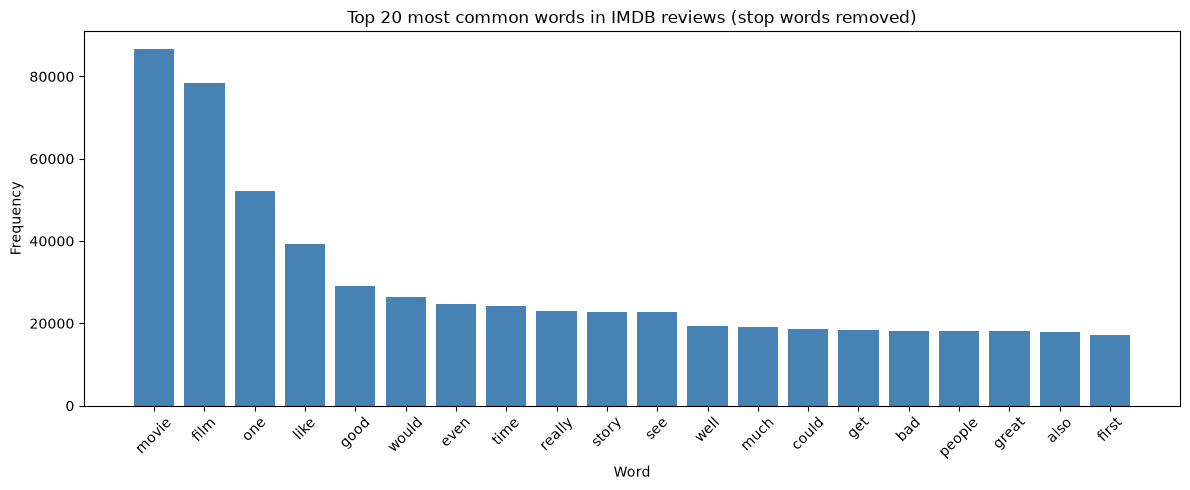

In [43]:
word_freq = Counter(word for toks in imdb_df['clean_tokens'] for word in toks)
top_words = word_freq.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 most common words in IMDB reviews (stop words removed)')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Results of the analysis

In [44]:
print('=' * 55)
print('IMDB REVIEWS – TEXT ANALYSIS RESULTS')
print('=' * 55)
print(f'Total number of reviews                      : {total_reviews}')
print(f'Average word count per review                : {avg_words:.2f}')
print(f'Average word count (after stop-word removal) : {avg_words_clean:.2f}')
print(f'Positive reviews (containing "good")         : {good_reviews}')
print(f'Negative reviews (containing "bad")          : {bad_reviews}')
print('\nTop 20 most common words:')
for word, count in top_words:
    print(f'  {word:<10} {count}')

IMDB REVIEWS – TEXT ANALYSIS RESULTS
Total number of reviews                      : 50000
Average word count per review                : 228.53
Average word count (after stop-word removal) : 114.88
Positive reviews (containing "good")         : 18702
Negative reviews (containing "bad")          : 11641

Top 20 most common words:
  movie      86642
  film       78392
  one        52263
  like       39271
  good       29100
  would      26496
  even       24794
  time       24130
  really     23077
  story      22743
  see        22736
  well       19466
  much       19172
  could      18546
  get        18326
  bad        18149
  people     18128
  great      18040
  also       17916
  first      17252


---
## Task #2: N-gram Generation from Poem Data

1. Load the dataset from a CSV file – [Poem Classification (NLP) | Kaggle](https://www.kaggle.com/datasets/ramjasmaurya/poem-classification-nlp)
2. Pre-process the text data: tokenize, remove punctuation, lowercase, remove English stop words
3. Generate bi-grams from the preprocessed text
4. Calculate the frequency of each unique bi-gram in the `bigrams` column
5. Display the top 10 most common bi-grams

### 1. Load the dataset

In [45]:
POEM_PATH = 'data/poem/Poem_classification - train_data.csv'

poem_df = pd.read_csv(POEM_PATH)
print(poem_df.shape)
poem_df = poem_df.dropna(subset=['Poem']).reset_index(drop=True)
print('After dropping empty poems:', poem_df.shape)
poem_df.head()

(841, 2)
After dropping empty poems: (837, 2)


,Genre,Poem
0,Music,In the thick brushthey spend the...
1,Music,Storms are generous. ...
2,Music,—After Ana Mendieta Did you carry around the ...
3,Music,for Aja Sherrard at 20The portent may itself ...
4,Music,"for Bob Marley, Bavaria, November 1980 Here i..."


### 2. Pre-process the text data

In [46]:
poem_df['tokens'] = poem_df['Poem'].apply(preprocess)
poem_df['clean_tokens'] = poem_df['tokens'].apply(lambda toks: [t for t in toks if t not in stop_words])
poem_df[['Poem', 'clean_tokens']].head()

,Poem,clean_tokens
0,In the thick brushthey spend the...,"[thick, brushthey, spend, hottest, part, day, ..."
1,Storms are generous. ...,"[storms, generous, something, easy, surrender,..."
2,—After Ana Mendieta Did you carry around the ...,"[ana, mendieta, carry, around, matin, star, ho..."
3,for Aja Sherrard at 20The portent may itself ...,"[aja, sherrard, portent, may, memory, wallace,..."
4,"for Bob Marley, Bavaria, November 1980 Here i...","[bob, marley, bavaria, november, brilliant, mo..."


### 3. Generate bi-grams

In [47]:
poem_df['bigrams'] = poem_df['clean_tokens'].apply(lambda toks: list(ngrams(toks, 2)))
poem_df[['clean_tokens', 'bigrams']].head()

,clean_tokens,bigrams
0,"[thick, brushthey, spend, hottest, part, day, ...","[(thick, brushthey), (brushthey, spend), (spen..."
1,"[storms, generous, something, easy, surrender,...","[(storms, generous), (generous, something), (s..."
2,"[ana, mendieta, carry, around, matin, star, ho...","[(ana, mendieta), (mendieta, carry), (carry, a..."
3,"[aja, sherrard, portent, may, memory, wallace,...","[(aja, sherrard), (sherrard, portent), (porten..."
4,"[bob, marley, bavaria, november, brilliant, mo...","[(bob, marley), (marley, bavaria), (bavaria, n..."


### 4. Frequency of each unique bi-gram

In [48]:
bigram_freq = Counter(bg for bgs in poem_df['bigrams'] for bg in bgs)
print('Total bi-grams       :', sum(bigram_freq.values()))
print('Unique bi-grams      :', len(bigram_freq))

Total bi-grams       : 20000
Unique bi-grams      : 18335


### 5. Top 10 most common bi-grams

In [49]:
top10_bigrams = pd.DataFrame(bigram_freq.most_common(10), columns=['bigram', 'frequency'])
top10_bigrams['bigram'] = top10_bigrams['bigram'].apply(' '.join)
top10_bigrams.index = top10_bigrams.index + 1
top10_bigrams

,bigram,frequency
1,let us,10
2,ah yes,8
3,every day,7
4,let go,6
5,first time,6
6,come back,6
7,parking lot,6
8,give us,6
9,died august,5
10,thou art,5


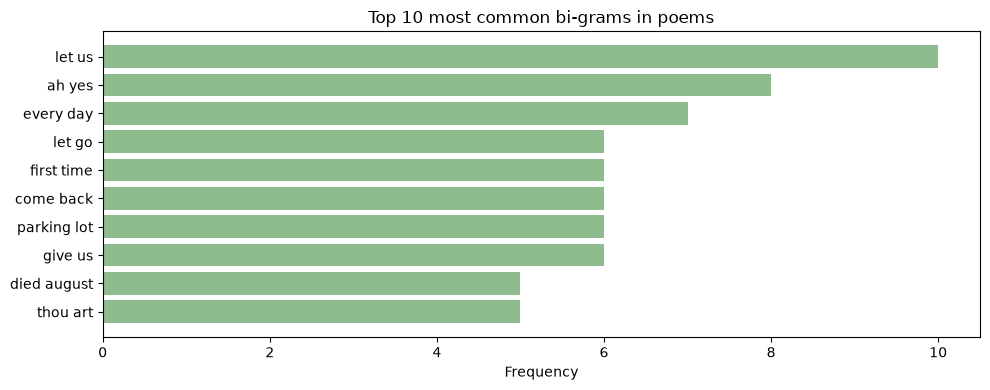

In [50]:
plt.figure(figsize=(10, 4))
plt.barh(top10_bigrams['bigram'][::-1], top10_bigrams['frequency'][::-1], color='darkseagreen')
plt.title('Top 10 most common bi-grams in poems')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()